#  import

In [11]:
import sys
from pathlib import Path

p = Path.cwd().resolve()
while p.name != "PEC" and p != p.parent:
    p = p.parent

sys.path.insert(0, str(p / "src"))
sys.path.insert(0, str(p / "examples" / "Teleportation"))

In [12]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
from PEC_sampler_package_teleportation import tele_PEC_Readout_Module_Sampler as pecro
from PEC_sampler_package_teleportation import tele_PEC_TQG_Module_Sampler as peccx
from PEC_sampler_package_teleportation import tele_PEC_sampler as pec
from PEC_sampler_package_teleportation import tele_Restore_Retrieve as RR
import tele_Fidelity as fdlt

import qiskit as q
from qiskit import QuantumCircuit
from qiskit.visualization import *
from qiskit.circuit.library import *
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_aer.primitives import SamplerV2
from qiskit_ibm_runtime import QiskitRuntimeService

In [13]:
token = "PJubuPXreZKAxan0yV6OLEIkdKipFYGgvvkGQSZAtpMU"
instance = 'crn:v1:bluemix:public:quantum-computing:us-east:a/f071734952cb4c9993a642d0a87d18bb:392306ae-fe55-475c-a8c5-978d0ba1871e::'
name = "fez"
device_name = "ibm_" + name
QiskitRuntimeService.save_account(
        channel="ibm_quantum_platform",
        token=token,
        instance=instance,
        set_as_default=True,
        overwrite=True
    )
service = QiskitRuntimeService()
device = service.backend(device_name)
noise_model = NoiseModel.from_backend(device)

In [14]:
backend = AerSimulator.from_backend(device)
backend_options = {
    # "method": "automatic",
    "noise_model": noise_model,
    "basis_gates": noise_model.basis_gates,
    "coupling_map": device.configuration().coupling_map,
    # parallelism knobs
    # "max_parallel_experiments":32,
    # "max_parallel_threads": 0
    # "device": "GPU",  # if you have qiskit-aer-gpu
}
run_options = {
    "shots": 1024,
    # "seed_simulator": 12345,
}

sampler = SamplerV2(
    options={
        "backend_options": backend_options,
        "run_options": run_options,
        # "default_precision": 0.0,  # if you want deterministic path where applicable
    }
)
sampler.mode=backend
backendqubitNum = backend.num_qubits
print(backendqubitNum)

156


# Build Teleportation Circuit

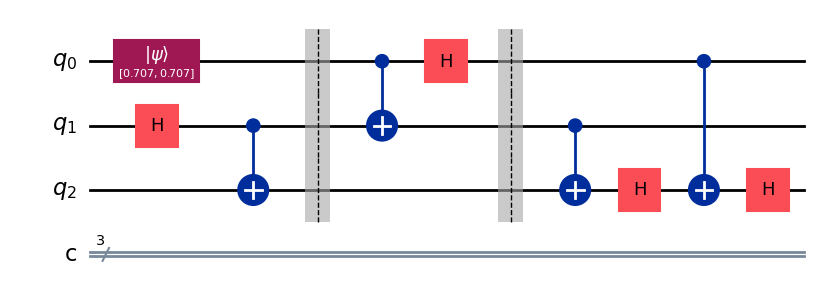

In [15]:
tele = QuantumCircuit(3, 3)

# State preparation 
a = 1/np.sqrt(2); b = 1/np.sqrt(2)
tele.initialize([a, b], 0)
tele.h(1)
tele.cx(1, 2)
tele.barrier()

# Teleportation circuit
tele.cx(0, 1)
tele.h(0)
# tele.measure([0, 1], [0, 1])
tele.barrier()
tele.cx(1, 2)
tele.h(2)
tele.cx(0, 2)
tele.h(2)
# tele.cx(1, 2).c_if(tele.clbits[1], 1)
# tele.cz(0, 2).c_if(tele.clbits[0], 1)
tele.draw('mpl')

# Calculate Readout PEC Observable

In [ ]:
importlib.reload(pecro)
pec_readout_info = pecro.readout_pec_sampler_subsystem(tele, sampler, backend, shots=1024, batch_mode=True, backend_options=backend_options)

In [20]:
print("cwd =", Path.cwd())
print("ROWeight exists? ", Path("ROWeight").exists())
print("timestamp dir exists? ", Path("ROWeight/20260413-101539").exists())
print("file exists? ", Path("ROWeight/20260413-101539/Oweights.pkl").exists())

cwd = /home/n96134289/PEC
ROWeight exists?  False
timestamp dir exists?  False
file exists?  False


In [19]:
# RR.save_readout_result(pec_readout_info, fname="Oweights", parent_dir="ROWeight")
pec_readout_info = RR.load_readout_result("ROWeight/20260413-101539/Oweights.pkl")

FileNotFoundError: [Errno 2] No such file or directory: 'ROWeight/20260413-101539/Oweights.pkl'

In [7]:
B = pec_readout_info["B"]
readout_weights = pec_readout_info["ReadoutWeight"]
print("B:", B, "\nReadoutWeight:", readout_weights)

B: [[ 1.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-1.04980469e-02  8.89404297e-01  4.15039062e-03 ...  2.68554688e-03
  -8.54492188e-03  2.44140625e-04]
 [-2.68554688e-03 -1.68457031e-02  8.77685547e-01 ...  3.05175781e-02
   1.78222656e-02  4.63867188e-03]
 ...
 [ 1.41601562e-02  4.88281250e-03 -2.29492188e-02 ...  6.17675781e-01
   3.02734375e-02 -1.75781250e-02]
 [ 2.07519531e-02 -2.75878906e-02 -1.58691406e-02 ... -1.14746094e-02
   6.00830078e-01 -7.32421875e-04]
 [ 1.78222656e-02 -2.27050781e-02 -3.58886719e-02 ...  1.78222656e-02
  -1.39160156e-02  5.89111328e-01]] 
ReadoutWeight: {'III': array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]]), 'IIX': array([[ 1.31040288e-02,  1.11130136e+0

# Calculate CNOT PEC Weight

In [ ]:
importlib.reload(peccx)
pack = peccx.compute_tqg_matrices(sampler, tele, shots=1024, obs_batch=1024)

In [ ]:
pec_tqg_info = peccx.averaged_pauli_twirling_matrix(pack, B=pec_readout_info["B"])
tqg_weights = peccx.compute_inv_weights_for_package(pec_tqg_info)
tqg_weights

In [ ]:
RR.save_vectors(tqg_weights, fname="Gweights", parent_dir="TQGWeight")

In [8]:
load_weights = RR.load_vectors("TQGWeight/20251126-172221/Gweights.npy")
tqg_weights = load_weights["vectors"]
tqg_weights

{(0,
  1): array([ 7.49475514e-01,  1.51197488e-02, -5.87153467e-04,  5.14544428e-03,
         2.47865451e-01, -4.60016170e-03,  1.47981377e-02,  5.19333053e-03,
        -2.04744418e-03, -8.20349751e-03,  4.85576918e-03,  3.01827159e-04,
        -6.74156489e-03,  4.69238584e-03,  2.81298423e-03,  3.54746378e-03,
        -1.81970955e-03,  1.57824826e-02, -2.81541087e-03, -5.32792882e-03,
        -1.66208273e-02, -6.58767882e-03,  6.44564381e-03,  8.65352223e-03,
         2.39156301e-01, -2.03730401e-02,  7.20572170e-03,  4.60031099e-03,
        -2.52353289e-01,  1.00966482e-02,  1.82947919e-03, -3.01533224e-03,
         4.66427313e-03, -6.79200647e-03, -4.87197708e-03, -5.62113156e-04,
         2.20593564e-02,  6.95654275e-03, -5.11636779e-03, -1.49408857e-02,
        -2.45519018e-01,  1.55555814e-02, -2.75221102e-03,  3.75493029e-04,
         2.50964256e-01, -9.41085994e-03, -9.23501438e-04,  7.02492106e-03,
         2.52929535e-01, -8.88253615e-03, -5.26725924e-03, -1.11973343e-02,
  

In [27]:
importlib.reload(pec)
importlib.reload(fdlt)
importlib.reload(RR)

<module 'PEC_sampler_package_teleportation.tele_Restore_Retrieve' from '/home/n96134289/PEC/src/PEC_sampler_package_teleportation/tele_Restore_Retrieve.py'>


[ PEC |w_prod| cumulative analysis ]
  twirled CNOT count : 3
  nonzero combos     : 262144
  gamma_total = Σ|w| : 2.381429e+01
  threshold          : 0.990
  keep K             : 42498
  kept ratio         : 0.990000
  eliminated ratio   : 0.010000


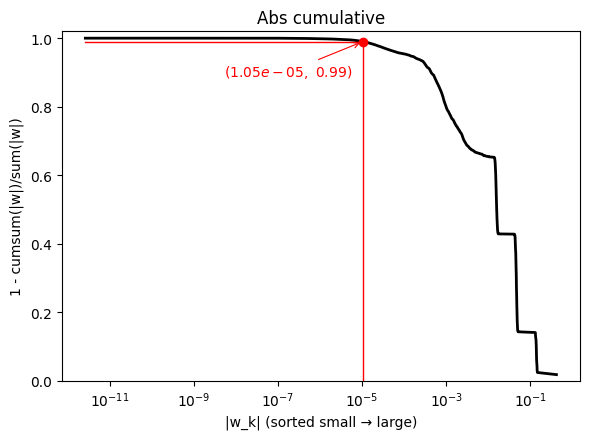

Figure1 intersection x = 1.045650265667517e-05


In [10]:
abs_w, cum_ratio, k = fdlt.analyze_tqg_weights_cumulative(
    tele,
    tqg_weights,
    threshold=0.99,
)

def first_crossing_x_on_logx(x_pos, y, y0):
    """
    找 y(x) 跟水平線 y=y0 的第一個交點（從 x 小→大掃描）
    x_pos 必須 >0，且已經是由小→大排序（你的 |w_k| sorting）
    回傳 x_intersect（在 log10(x) 空間做線性插值）
    """
    x = np.asarray(x_pos, dtype=float)
    y = np.asarray(y, dtype=float)

    d = y - y0
    # 找第一個 sign change（含剛好等於0）
    for i in range(len(d) - 1):
        if d[i] == 0:
            return x[i]
        if d[i] * d[i+1] < 0:   # 真的跨過去
            # log-x interpolation
            lx0, lx1 = np.log10(x[i]), np.log10(x[i+1])
            yA, yB = y[i], y[i+1]
            # y = yA + t*(yB-yA) ; solve for t
            t = (y0 - yA) / (yB - yA)
            lx = lx0 + t * (lx1 - lx0)
            return 10**lx
        if d[i] > 0 and d[i+1] == 0:
            return x[i+1]
    # 沒交點就回傳 None
    return None

x = abs_w                 # 已經是由大到小排序
y = cum_ratio             # 剩餘的 |w| 比例
y0 = 0.99                 #你要標的水平線

# ===== 找交點（各找各的，保證點在黑線上）=====
x1 = first_crossing_x_on_logx(x, y, y0)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(x, y, color="black", lw=2)          # 用連線，交點會精準落在曲線上
ax.plot([x[-1], x1], [y0, y0], color="red", lw=1)
ax.plot([x1, x1], [0, y0], color="red", lw=1)
ax.plot(x1, y0, "o", color="red")
label = rf"$({x1:.2e},\ {y0:.2f})$"         # 標出點座標
ax.annotate(label, xy=(x1, y0), xytext=(-100, -25),              # 文字偏移（pixel）
            textcoords="offset points", fontsize=10,
            color="red", arrowprops=dict(arrowstyle="->", color="red", lw=0.8))


ax.set_xscale("log")
ax.set_ylim(0, 1.02)
ax.set_ylabel("1 - cumsum(|w|)/sum(|w|)")
ax.set_xlabel("|w_k| (sorted small → large)")
ax.set_title("Abs cumulative")

plt.tight_layout()
plt.show()

print("Figure1 intersection x =", x1)


In [ ]:
# 2) 你的 readout 與 TQG 權重
# readout_weight: {'XX': w_vec(16), 'ZX': ..., 'XZ': ..., 'ZZ': ...}
# weights_map_tqg: {(c,t): np.ndarray length 4^n}  (n=電路總 qubits；或 m=active 也行，只要一致)
state = [a, b]
server_id = 2
n_trials=61
S_pec, S_nopec, summary, meas_pec, meas_nopec, diag_records = fdlt.compare_pec_vs_nopec_sampler(
    sampler=sampler,
    state=state,
    tqg_weights=tqg_weights,
    readout_weights=readout_weights,
    n_trials=n_trials,
    backend=backend,
    opt_level=0,
    shots=1024,
    combo_batch_size=256,
    max_batch=2048,
    # segment_id=server_id-1, 
    # segment_count=2,
    trunc_threshold=0.99,
    log_path="./logs/202604031001_100_trials_0.707.jsonl"
)

print("=== Summary over trials ===")
print(summary)


[ Phase-0 PEC truncation analysis ]
  twirled CNOT count : 3
  nonzero combos     : 262144
  gamma_total = Σ|w| : 2.381429e+01
  cutoff |w|         : 1.0456380337591951e-05
  cutoff signed w    : -1.0456380337591951e-05
  cumulative ratio at cutoff : 0.9900001886291838
  keep K             : 42498
  kept ratio         : 0.990000
Segment 1/1: kept-set 0..42497 (total 42498)
[flush 1] START max_batch reached | submit 2048 circs | terms 32/42498 (0.1%)
[flush 1] max_batch reached | ran 2048 circs (cum 2048) | 59.46s | terms 32/42498 (0.1%)
[flush 2] START max_batch reached | submit 2048 circs | terms 65/42498 (0.2%)
[flush 2] max_batch reached | ran 2048 circs (cum 4096) | 68.39s | terms 65/42498 (0.2%)
[flush 3] START max_batch reached | submit 2048 circs | terms 97/42498 (0.2%)
[flush 3] max_batch reached | ran 2048 circs (cum 6144) | 62.83s | terms 97/42498 (0.2%)
[flush 4] START max_batch reached | submit 2048 circs | terms 130/42498 (0.3%)
[flush 4] max_batch reached | ran 2048 circ

In [21]:
experiment_results={
    "S_pec": S_pec,
    "S_nopec": S_nopec,
    "summary": summary,
    "meas_pec": meas_pec,
}
RR.save_experiment_results(experiment_results, fname = "teleportation", parent_dir = "fidelity_results")
# with open("BellState_results/20251118-114007/bellstate.pkl", "rb") as f: data = pickle.load(f)
print(experiment_results)

Saved to: fidelity_results/20260403-114847/teleportation.pkl
{'S_pec': [0.949720384, 1.054227098, 0.992115631, 0.950442143, 0.995675782, 0.960501853, 0.957734076, 1.039383319, 1.069088884, 0.936844073, 0.92680048, 0.993426207, 0.962806527, 1.07452102, 1.033858788, 0.966126003, 0.917951409, 0.972688718, 0.926806753, 1.001494587, 1.033703106, 1.006302596, 0.982581565, 1.008875909, 1.022989052, 0.953241946, 1.008600128, 0.939429851, 1.064754557, 1.013410686, 1.003076897, 1.029390398, 0.925383425, 1.010144627, 1.0480863, 0.902242371, 1.057361609, 1.030303274, 0.965745541, 0.993800716, 0.885936903, 1.020866131, 1.069188604, 1.00081795, 0.949460268, 0.949210168, 0.910598746, 0.990757284, 1.047542302, 1.017257192, 0.999511355, 0.952123644, 1.029158603, 1.018024992, 0.98966488, 0.973924612, 0.994118495, 1.023345456, 0.95882781, 1.007598077, 1.059994891, 1.009882071, 1.032191922, 1.00302218, 1.05739522, 1.028937541, 0.979575569, 0.985998295, 0.985768625, 1.035743538, 0.967536882, 1.014396052, 1

In [18]:
S_nopec = [0.9321875 , 0.94003906, 0.88203125, 0.87285156, 0.89085938, 0.88449219, 0.8825    , 0.91683594, 0.874375  , 0.92863281,
           0.87707031, 0.86210937, 0.92449219, 0.87929687, 0.88449219, 0.94125   , 0.88039062, 0.91886719, 0.92320312, 0.91757813,
           0.87804688, 0.90496094, 0.91542969, 0.92800781, 0.92007813, 0.89613281, 0.91667969, 0.87773437, 0.88355469, 0.91921875,
           0.89183594, 0.87371094, 0.88660156, 0.91160156, 0.92539062, 0.88042969, 0.88820312, 0.9403125 , 0.92574219, 0.93570312,
           0.87355469, 0.91835938, 0.93535156, 0.89191406, 0.89460938, 0.86636719, 0.88460937, 0.92070312, 0.86402344, 0.93371094,
           0.87097656, 0.87324219, 0.88117188, 0.93191406, 0.87265625, 0.87351563, 0.92675781, 0.89417969, 0.91828125, 0.87898437,
           0.89328125, 0.93886719, 0.91449219, 0.92742188, 0.87332031, 0.896875  , 0.87519531, 0.87726563, 0.89160156, 0.93308594,
           0.92515625, 0.88480469, 0.90253906, 0.9190625 , 0.91238281, 0.91289063, 0.89617187, 0.91816406, 0.92914062, 0.93792969,
           0.89980469, 0.91550781, 0.87027344, 0.88820313, 0.94144531, 0.89519531, 0.93546875, 0.873125  , 0.9159375 , 0.87917969,
           0.93988281, 0.88851562, 0.92980469, 0.92902344, 0.9303125 , 0.93183594, 0.93597656, 0.89558594, 0.87296875, 0.92289063]
# S_pec = [1.02578586, 1.01909201, 0.98948452, 0.88810680, 0.99034215, 0.94984225, 1.06196836, 1.08283221, 1.05870210]
S_pec = [0.949720384, 1.054227098, 0.992115631, 0.950442143, 0.995675782, 0.960501853, 0.957734076, 1.039383319, 1.069088884, 0.936844073, 
         0.926800480, 0.993426207, 0.962806527, 1.074521020, 1.033858788, 0.966126003, 0.917951409, 0.972688718, 0.926806753, 1.001494587, 
         1.033703106, 1.006302596, 0.982581565, 1.008875909, 1.022989052, 0.953241946, 1.008600128, 0.939429851, 1.064754557, 1.013410686, 
         1.003076897, 1.029390398, 0.925383425, 1.010144627, 1.048086300, 0.902242371, 1.057361609, 1.030303274, 0.965745541, 0.993800716, 
         0.885936903, 1.020866131, 1.069188604, 1.000817950, 0.949460268, 0.949210168, 0.910598746, 0.990757284, 1.047542302, 1.017257192, 
         0.999511355, 0.952123644, 1.029158603, 1.018024992, 0.989664880, 0.973924612, 0.994118495, 1.023345456, 0.958827810, 1.007598077, 
         1.059994891, 1.009882071, 1.032191922, 1.003022180, 1.057395220, 1.028937541, 0.979575569, 0.985998295, 0.985768625, 1.035743538, 
         0.967536882, 1.014396052, 1.027925776, 1.013021051, 1.032506701, 0.928832358, 0.977700456, 0.949256618, 1.033197508, 1.016915432, 
         1.062954920, 1.025584242, 1.080736885, 1.048244572, 0.987872628, 0.966905907, 0.931663825, 1.017854684, 0.946065334, 0.943532066, 
         0.968698561, 0.979174089, 0.948778087, 1.024728690, 0.992967972, 1.000502835, 1.049797252, 1.026054543, 0.970982947, 0.915048180]

n_trials = 100
summary["noPEC_mean"] = np.mean(S_nopec)
summary["PEC_mean"] = np.mean(S_pec)
summary["noPEC_std"] = np.std(S_nopec)
summary["PEC_std"] = np.std(S_pec)

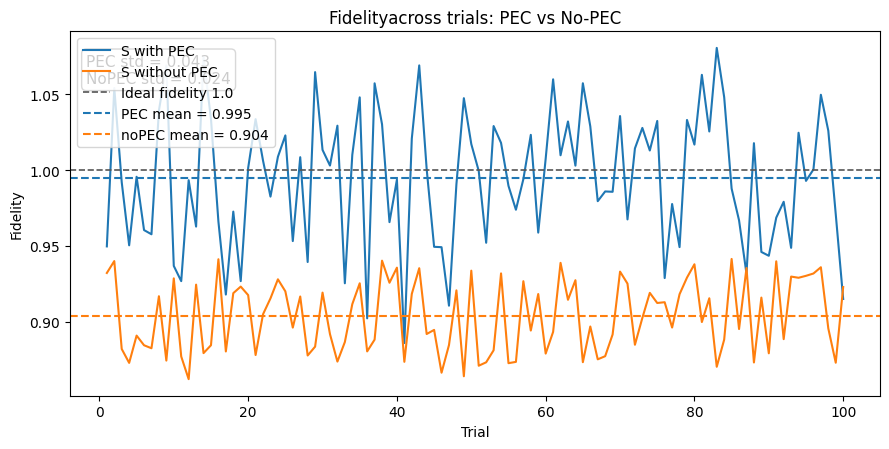

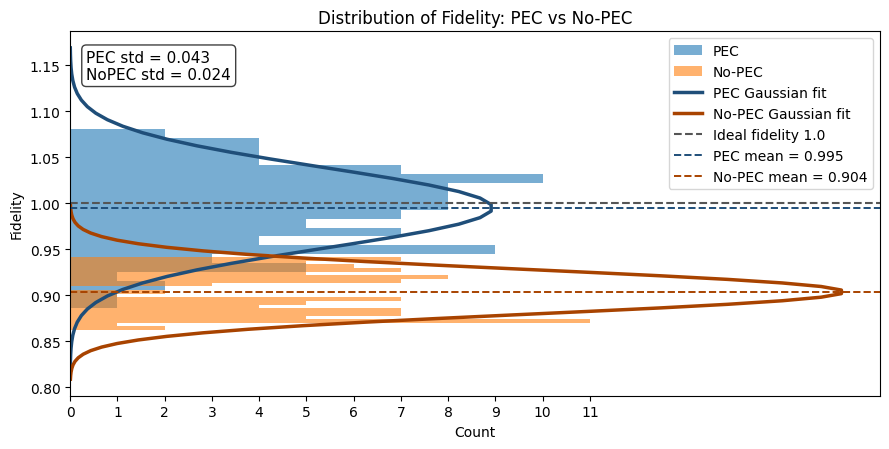

[SAVE] Fidelity_trial → output_graph/20260403-114745_100/Fidelity_trial.png
[SAVE] Fidelity_distribution → output_graph/20260403-114745_100/Fidelity_distribution.png


In [20]:
# ======  畫圖：折線 + 兩條平均線；以及分布（直方圖） ======
dark_gray = "#555555"  
pec_gauss_color = "#1f4e79"     # 深藍
nopec_gauss_color = "#a84300"   # 深橘

# ======  折線圖（每次 trial 的 S 值） ====== 
plt.figure(figsize=(9,4.6))
fig_trial = plt.gcf() 
line_pec, = plt.plot(range(1, n_trials+1), S_pec, label="S with PEC")
line_nopec, = plt.plot(range(1, n_trials+1), S_nopec, label="S without PEC")
plt.axhline(1, linestyle="--", linewidth=1.2, color=dark_gray, label="Ideal fidelity 1.0")
plt.axhline(summary["PEC_mean"], linestyle="--", color=line_pec.get_color(), label=f"PEC mean = {summary['PEC_mean']:.3f}")
plt.axhline(summary["noPEC_mean"], linestyle="--", color=line_nopec.get_color(), label=f"noPEC mean = {summary['noPEC_mean']:.3f}")
plt.xlabel("Trial")
plt.ylabel("Fidelity")
plt.title("Fidelityacross trials: PEC vs No-PEC")
textstr = (
    f"PEC std = {summary['PEC_std']:.3f}\n"
    f"NoPEC std = {summary['noPEC_std']:.3f}"
)
plt.gca().text(
    0.02, 0.85, textstr,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='bottom',
    horizontalalignment='left',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.75)
)
plt.legend()
plt.tight_layout()
plt.show()

# ======  直方圖（分布比較） ====== 
plt.figure(figsize=(9,4.6))
fig_dist = plt.gcf() 
n_pec, bins_pec, patches_pec = plt.hist(S_pec, bins=max(10, n_trials//5), alpha=0.6, label="PEC", orientation="horizontal")
n_nopec, bins_nopec, patches_nopec = plt.hist(S_nopec, bins=max(10, n_trials//5), alpha=0.6, label="No-PEC", orientation="horizontal")

# ====== 加入高斯擬合曲線 ======
# 取 bin 寬（PEC / No-PEC 用同一個 bins 效果最好）
bin_width = bins_pec[1] - bins_pec[0]
# S 軸取平滑網格
S_pec_grid = np.linspace(summary["PEC_mean"] - 4 * summary["PEC_std"], summary["PEC_mean"] + 4 * summary["PEC_std"])
S_nopec_grid = np.linspace(summary["noPEC_mean"] - 4 * summary["noPEC_std"], summary["noPEC_mean"] + 4 * summary["noPEC_std"])
def gaussian_pdf(x, mu, sigma): return (1.0 / (sigma * np.sqrt(2*np.pi))) * np.exp(-0.5 * ((x - mu)/sigma)**2)
# PEC 高斯 → 轉成 count 尺度
x_gauss_pec = (n_trials * bin_width * gaussian_pdf(S_pec_grid, summary["PEC_mean"], summary["PEC_std"]))
# No-PEC 高斯 → 轉成 count 尺度
x_gauss_nopec = (n_trials * bin_width * gaussian_pdf(S_nopec_grid, summary["noPEC_mean"], summary["noPEC_std"]))
# 畫曲線（用 histogram 的顏色，視覺一致）
plt.plot(x_gauss_pec, S_pec_grid, color=pec_gauss_color, linewidth=2.5, label="PEC Gaussian fit")
plt.plot(x_gauss_nopec, S_nopec_grid, color=nopec_gauss_color, linewidth=2.5,  label="No-PEC Gaussian fit")

# ====== Average Line ======
plt.axhline(1, linestyle="--", color=dark_gray, label="Ideal fidelity 1.0")
plt.axhline(summary["PEC_mean"], linestyle="--", color=pec_gauss_color, linewidth=1.4, label=f"PEC mean = {summary['PEC_mean']:.3f}")
plt.axhline(summary["noPEC_mean"], linestyle="--", color=nopec_gauss_color, linewidth=1.4, label=f"No-PEC mean = {summary['noPEC_mean']:.3f}")
max_count = int(max(n_pec.max(), n_nopec.max()))
plt.xticks(range(max_count + 1))
plt.xlabel("Count")
plt.ylabel("Fidelity")
plt.title("Distribution of Fidelity: PEC vs No-PEC")
textstr = (
    f"PEC std = {summary['PEC_std']:.3f}\n"
    f"NoPEC std = {summary['noPEC_std']:.3f}"
)
plt.gca().text(
    0.02, 0.95, textstr,
    transform=plt.gca().transAxes,
    fontsize=11,
    verticalalignment='top',
    horizontalalignment='left',
    bbox=dict(boxstyle="round", facecolor="white", alpha=0.75)
)
plt.legend()
plt.tight_layout()
plt.show()
save_dir = RR.save_fidelity_figures(fig_trial, fig_dist, n_trials, parent_dir="output_graph")